In [ ]:
from google.colab import files
uploaded = files.upload()


Saving marketing_AB.csv to marketing_AB.csv


In [ ]:
import pandas as pd
df = pd.read_csv('marketing_AB.csv')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv('marketing_AB.csv')
print(df.head())
print(df.shape)
print(df.info())

   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  
(588101, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588

In [ ]:
print(df['test group'].value_counts())
print(df['converted'].value_counts())

test group
ad     564577
psa     23524
Name: count, dtype: int64
converted
False    573258
True      14843
Name: count, dtype: int64


In [ ]:
conversion_rate = df.groupby('test group')['converted'].mean() * 100
print(conversion_rate)

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


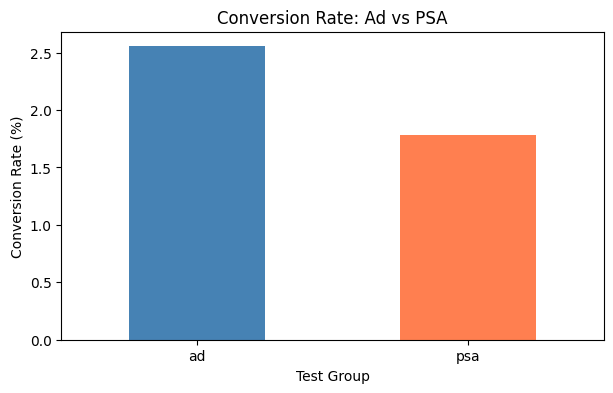

In [ ]:
conversion_rate.plot(kind='bar', color=['steelblue', 'coral'], figsize=(7,4))
plt.title('Conversion Rate: Ad vs PSA')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Test Group')
plt.xticks(rotation=0)
plt.show()

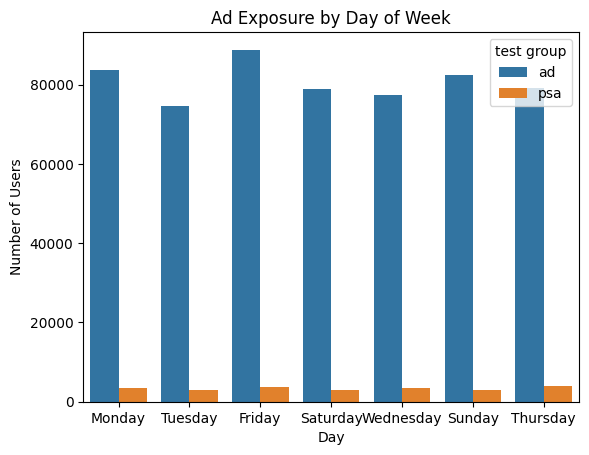

In [ ]:
sns.countplot(data=df, x='most ads day', hue='test group')
plt.title('Ad Exposure by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Users')
plt.show()

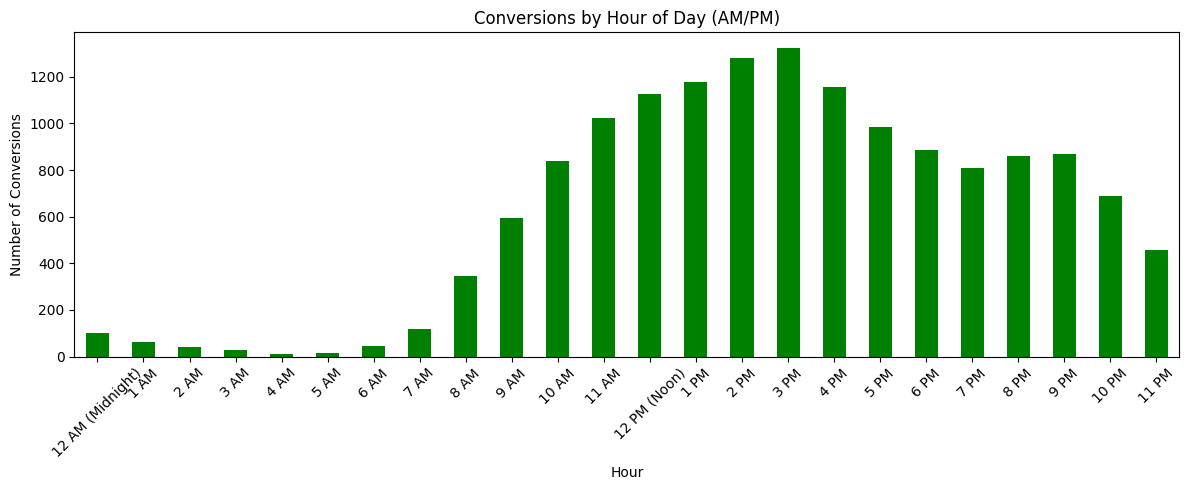

In [ ]:
# Convert hour numbers to AM/PM format
def convert_to_ampm(hour):
    if hour == 0:
        return '12 AM (Midnight)'
    elif hour < 12:
        return f'{hour} AM'
    elif hour == 12:
        return '12 PM (Noon)'
    else:
        return f'{hour - 12} PM'

# Apply to the chart
converted_df = df[df['converted'] == True]

# Count conversions per hour
hourly_conversions = converted_df['most ads hour'].value_counts().sort_index()

# Convert index to AM/PM labels
hourly_conversions.index = [convert_to_ampm(h) for h in hourly_conversions.index]

# Plot
plt.figure(figsize=(12, 5))
hourly_conversions.plot(kind='bar', color='green')
plt.title('Conversions by Hour of Day (AM/PM)')
plt.xlabel('Hour')
plt.ylabel('Number of Conversions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("""
HYPOTHESIS TEST
===============
Null Hypothesis (H0): There is NO difference in conversion rate
between users who saw Ads vs PSAs.

Alternative Hypothesis (H1): Users who saw Ads convert MORE
than users who saw PSAs.

Significance Level: 0.05 (95% confidence)
""")


HYPOTHESIS TEST
Null Hypothesis (H0): There is NO difference in conversion rate 
between users who saw Ads vs PSAs.

Alternative Hypothesis (H1): Users who saw Ads convert MORE 
than users who saw PSAs.

Significance Level: 0.05 (95% confidence)



In [ ]:
# Build contingency table
contingency_table = pd.crosstab(df['test group'], df['converted'])
print("Contingency Table:")
print(contingency_table)

# Run the test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\n✅ Result is SIGNIFICANT — Ads make a real difference!")
else:
    print("\n❌ Result is NOT significant — difference may be due to chance.")

Contingency Table:
converted    False  True 
test group               
ad          550154  14423
psa          23104    420

Chi-Square Statistic: 54.0058
P-value: 0.0000
Degrees of Freedom: 1

✅ Result is SIGNIFICANT — Ads make a real difference!


In [ ]:
ad_rate = df[df['test group'] == 'ad']['converted'].mean()
psa_rate = df[df['test group'] == 'psa']['converted'].mean()

lift = ((ad_rate - psa_rate) / psa_rate) * 100

print(f"Ad Group Conversion Rate:  {ad_rate:.2%}")
print(f"PSA Group Conversion Rate: {psa_rate:.2%}")
print(f"Lift from running Ads:     {lift:.2f}%")

Ad Group Conversion Rate:  2.55%
PSA Group Conversion Rate: 1.79%
Lift from running Ads:     43.09%


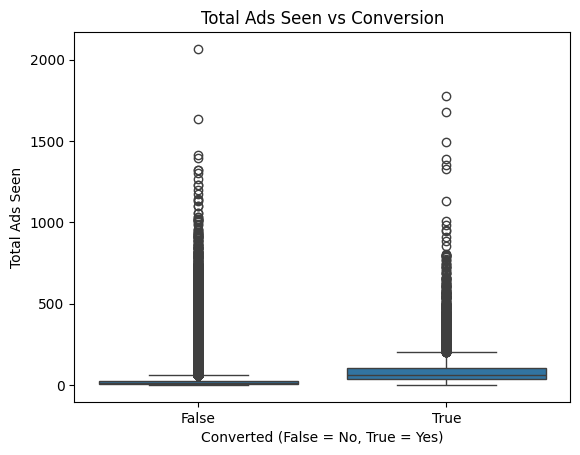

In [ ]:
sns.boxplot(data=df, x='converted', y='total ads')
plt.title('Total Ads Seen vs Conversion')
plt.xlabel('Converted (False = No, True = Yes)')
plt.ylabel('Total Ads Seen')
plt.show()